In [5]:
from sklearn.datasets import load_iris
import seaborn as sns

iris=load_iris()
x=iris.data
y=iris.target


In [7]:
#SCALING
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)


In [11]:
#DIMENSIONALITY REDUCTION USING PCA
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
pca_data=pca.fit_transform(x_scaled)

In [19]:
#Finding optimal K
from sklearn.cluster import KMeans
wcss=[]
for k in range(1,11):
    kmeans=KMeans(k)
    labels=kmeans.fit_predict(pca_data)
    wcss.append(kmeans.inertia_)

from kneed import KneeLocator
knee=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
print("Optimal K : ",knee.elbow)

Optimal K :  3


<Axes: >

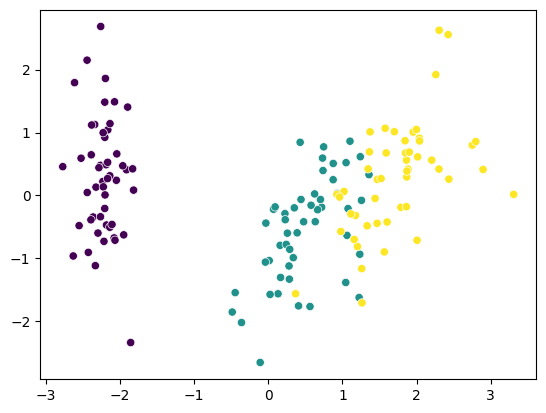

In [20]:

kmeans=KMeans(3)
labels=kmeans.fit_predict(pca_data)
sns.scatterplot(x=pca_data[:,0],y=pca_data[:,1],c=y)
sns.scatterplot(x=kmeans.cluster_centers_[:,0],y=kmeans.cluster_centers_[